# Case study 2: 16 DOF = 4 x 4-DOF

Four 4-DOF subsystems. Every subsystem has its own sensors, noise level, task, filter and integrator: the grounded one identifies a stiffness from two accelerometers (UKF), the second only tracks its states from two displacement sensors (linear KF), the third identifies a stiffness and a damping from accelerometers alone (CKF), and the last one identifies a stiffness from a single displacement sensor on the free end (UKF, RK4).

The chain has non-uniform masses, stiffnesses and dampings, random forces act on
every mass, and messages are mean interface forces exchanged with the
**jacobi** schedule. The measurement covariance is inflated
10x to account for the message error (see [Concepts](../concepts.md)).

The paper-length horizon is 20 s at 1 ms; set `PCI_T` to shorten it. Set
`RUN_CENTRAL = True` to also run a single UKF on the full augmented state for
comparison.

In [1]:
import os

from _support import build, centralized, compare_with_yaml, print_design, report

N_DOF = 16
PARTITION = [[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16]]
NAMES = ['S1', 'S2', 'S3', 'S4']
SCHEDULE = "jacobi"
DT, T = 1e-3, float(os.environ.get("PCI_T", 20.0))
R_INFLATION = 10.0     # R = (10 x sensor noise)^2, needed with mean-only messages
RUN_CENTRAL = False

## Design: one line per subsystem

Filter, integrator, sensors with their noise standard deviation, and the unknowns as
a fraction of the true value used for the initial guess.

In [2]:
DESIGN = [
    dict(filter='ukf', integrator='heun', sensors={'a1': 0.005, 'a4': 0.005}, unknowns={'k2': 0.7}),  # grounded: accelerations only
    dict(filter='kf', integrator='heun', sensors={'x6': 0.0001, 'x8': 0.0001}, unknowns={}),  # two displacement sensors, states only
    dict(filter='ckf', integrator='heun', sensors={'a10': 0.01, 'a12': 0.01}, unknowns={'k11': 0.6, 'c11': 0.5}),  # accelerometers only, two unknowns
    dict(filter='ukf', integrator='rk4', sensors={'x16': 0.001}, unknowns={'k15': 1.4}),  # a single displacement sensor, RK4
]
LOADS = {d: {"type": "random", "std": 400.0, "seed": 20 + d} for d in range(1, N_DOF + 1)}

## Physical system, synthetic data, decomposition

In [3]:
chain, truth_dict, data, system, unknowns, sensors, noise = build(N_DOF, PARTITION, NAMES, DESIGN, LOADS, DT, T, SCHEDULE, R_INFLATION)
print_design("16 DOF = 4 x 4-DOF", NAMES, PARTITION, DESIGN, DT, T, SCHEDULE, R_INFLATION)

16 DOF = 4 x 4-DOF   schedule = jacobi   dt = 0.001   T = 20.0 s   steps = 20000   R inflation = 10x
----------------------------------------------------------------------------------------------------
subsystem DOFs              filter  integrator  task                      sensors (noise std)                     
S1        [1, 2, 3, 4]      ukf     heun        joint: k2                 a1 (0.005), a4 (0.005)                  
S2        [5, 6, 7, 8]      kf      heun        state estimation          x6 (0.0001), x8 (0.0001)                
S3        [9, 10, 11, 12]   ckf     heun        joint: k11, c11           a10 (0.01), a12 (0.01)                  
S4        [13, 14, 15, 16]  ukf     rk4         joint: k15                x16 (0.001)                             


## Distributed estimation

In [4]:
res = system.estimate(data, loads={f"f{d}": v for d, v in LOADS.items()}, dt=DT, T=T, truth=truth_dict)
report(res, chain.parameters, unknowns, NAMES, PARTITION, T)

Distributed run time: 19.1 s (sequential; ~4.8 s with one core per subsystem)

parameter       true   initial       final  error %  post. std
k2           56443.8   39510.7     55437.4    -1.78        369
k11          62334.6   37400.8     60677.2    -2.66        422
c11            220.0     110.0       217.0    -1.38       25.6
k15          57569.2   80596.9     63663.1   +10.59   1.71e+03

subsystem   disp. NRMSE (2nd half)   vel. NRMSE (2nd half)
S1                          0.215%                  0.218%
S2                          0.167%                  0.593%
S3                          0.287%                  0.798%
S4                          0.380%                  1.816%
interface-force NRMSE (2nd half): F_k5 0.30%, F_k9 0.85%, F_k13 1.57%


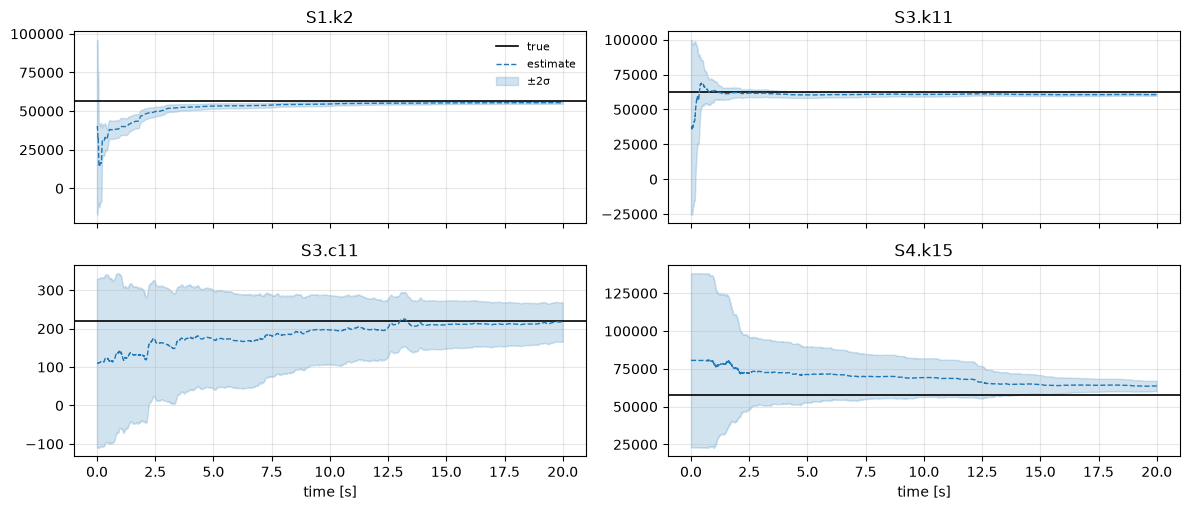

In [5]:
res.plot_parameters();

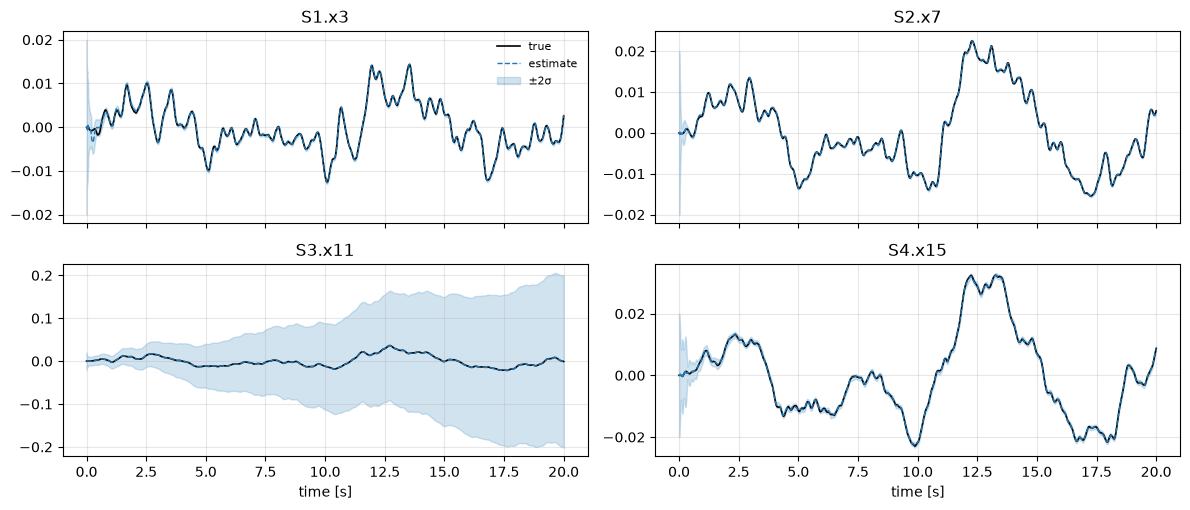

In [6]:
res.plot_states([f"{name}.x{g[len(g) // 2]}" for name, g in zip(NAMES, PARTITION)][:6]);

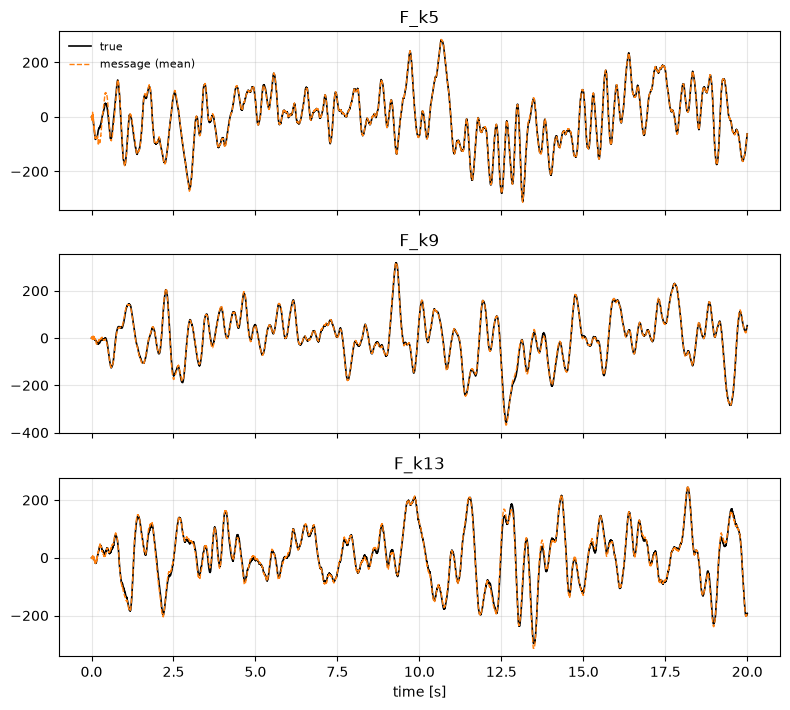

In [7]:
res.plot_messages();

## Centralized comparison (optional)

In [8]:
if RUN_CENTRAL:
    centralized(chain, N_DOF, unknowns, sensors, noise, data, LOADS, DT, T, truth_dict, R_INFLATION, res)

## The YAML twin

`02_case_16dof.yaml` describes the identical problem; with the full 20 s horizon it
reproduces the Python-API result to machine precision.

In [9]:
if T == 20.0:
    compare_with_yaml(res, "02_case_16dof.yaml", unknowns)

YAML twin (02_case_16dof.yaml): k2=55437.4, k11=60677.2, c11=217.0, k15=63663.1   max relative difference to Python API: 0.00e+00


Stiffness errors stay below a few percent except for k15, identified from one sensor on the free end. Free-floating subsystems that carry only accelerometers show a slowly growing displacement uncertainty (their rigid-body mode is unobservable to the local filter with mean-only messages); a single displacement sensor per subsystem removes it.